# Imports & Configuration

In [1]:
import tensorflow as tf
import numpy as np
import os
import pickle
import shutil
from tensorflow.keras import applications, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.models import load_model
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from IPython.display import Video
from tqdm import tqdm
from shapely.geometry import Polygon
from ultralytics import YOLO

I0000 00:00:1778523078.710765   23148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778523078.711317   23148 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778523078.746725   23148 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778523079.963877   23148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Configuration
source_root = 'cropped_img'
base_dir = 'prepared_data'
# Clean up existing prepared_data if any
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Your new 2 classes
classes = ['Reserved', 'Unreserved']

# Create destination folders
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Process Files
for cls in classes:
    src_path = os.path.join(source_root, cls)

    # Check if folder exists
    if not os.path.exists(src_path):
        print(f"Warning: Folder {src_path} not found. Skipping...")
        continue

    # List all images
    files = [f for f in os.listdir(src_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(files) == 0:
        print(f"No images found in {src_path}")
        continue

    # Split 80% train, 20% test
    train_files, test_files = train_test_split(files, test_size=0.20, random_state=42)

    # Helper function to copy
    def copy_files(file_list, split_name):
        for f in file_list:
            src = os.path.join(src_path, f)
            dst = os.path.join(base_dir, split_name, cls, f)
            shutil.copy(src, dst)

    copy_files(train_files, 'train')
    copy_files(test_files, 'test')

print(f"Data reorganized successfully! Classes: {classes}")

Data reorganized successfully! Classes: ['Reserved', 'Unreserved']


# Part 1: VGG16 Model

In [3]:
img_width, img_height = 48, 48
train_data_dir = 'prepared_data/train'
validation_data_dir = 'prepared_data/test'
batch_size = 32
epochs = 15

# Data Augmentation helps "equilibrate" the learning process
# by creating variations of minority classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

# This handles the "equilibrated" weight calculation automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))

print(f"Weights to balance classes: {train_class_weights}")

Found 398 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Weights to balance classes: {0: np.float64(0.796), 1: np.float64(1.3445945945945945)}


In [4]:
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

for layer in base_model.layers:
    layer.trainable = False


model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


E0000 00:00:1778523086.092369   23148 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778523086.106256   23148 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights
)

model.save('vgg16_model.h5')

Epoch 1/15


I0000 00:00:1778523087.280621   23148 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - accuracy: 0.8191 - loss: 0.4050 - val_accuracy: 0.9800 - val_loss: 0.1057
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9623 - loss: 0.0889 - val_accuracy: 0.9900 - val_loss: 0.0457
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.9824 - loss: 0.0582 - val_accuracy: 0.9900 - val_loss: 0.0398
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.9925 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0429
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.9975 - loss: 0.0251 - val_accuracy: 0.9900 - val_loss: 0.0397
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.9899 - loss: 0.0393 - val_accuracy: 0.9900 - val_loss: 0.0462
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.9950 - loss: 0.0308 - val_accuracy: 0.9900 - val_loss: 0.0377
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.9950 - loss: 0.0201 - val_accuracy: 0.9900 - val_

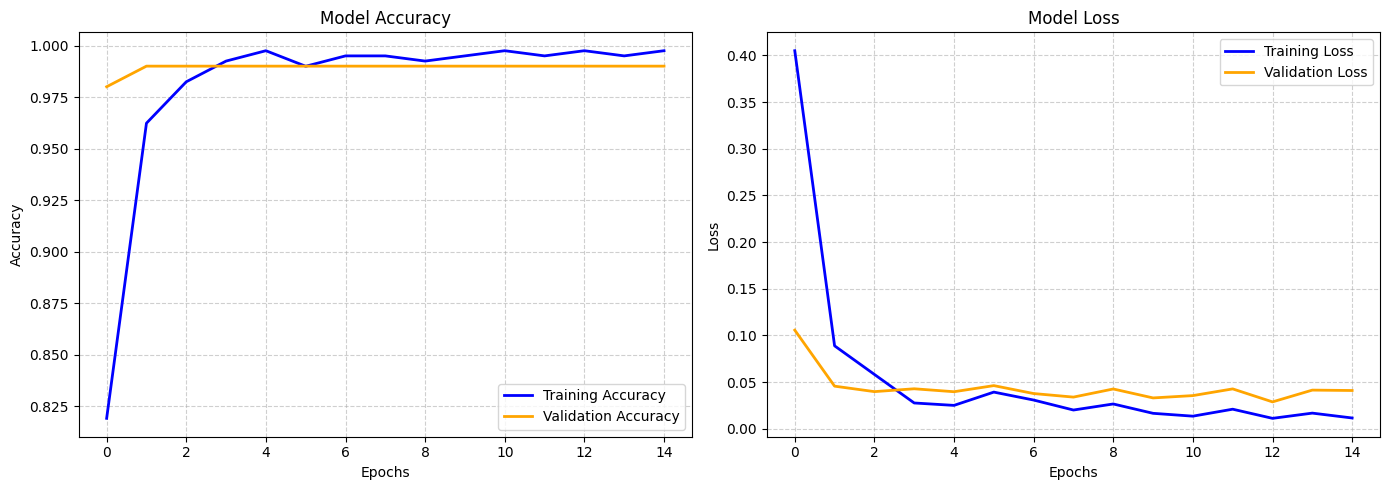

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

# Part 2: MobileNetV2 Model

In [8]:
img_width, img_height = 40, 65
train_data_dir = 'prepared_data/train'
validation_data_dir = 'prepared_data/test'
batch_size = 32
epochs = 35

# Data Augmentation helps "equilibrate" the learning process
# by creating variations of minority classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    # added:
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    interpolation='lanczos'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    interpolation='lanczos'
)

# This handles the "equilibrated" weight calculation automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))

print(f"Weights to balance classes: {train_class_weights}")

Found 398 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Weights to balance classes: {0: np.float64(0.796), 1: np.float64(1.3445945945945945)}


In [9]:
# base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# base_model = applications.EfficientNetB0(weights='imagenet',
                                          # include_top=False,
                                          # input_shape=(img_width, img_height, 3))
base_model = applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.25), # Réduit un peu pour éviter l'underfitting
    Dense(1, activation='sigmoid') # On reste en binaire
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/tmp/ipykernel_23148/3098536573.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 1,854,593 (7.07 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [11]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights,
    callbacks=[
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
        callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True),
        callbacks.ModelCheckpoint('mobilenetv2_best_model.h5', save_best_only=True, monitor='val_loss')
    ]
)

model.save('mobilenet_model.h5')

Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6258 - loss: 0.6954

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.6558 - loss: 0.6603 - val_accuracy: 0.5300 - val_loss: 0.7165 - learning_rate: 1.0000e-05
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7460 - loss: 0.5593

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.7462 - loss: 0.5389 - val_accuracy: 0.7100 - val_loss: 0.5485 - learning_rate: 1.0000e-05
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8084 - loss: 0.4551

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.8191 - loss: 0.4381 - val_accuracy: 0.8100 - val_loss: 0.4281 - learning_rate: 1.0000e-05
Epoch 4/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8318 - loss: 0.4186

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.8442 - loss: 0.4087 - val_accuracy: 0.8500 - val_loss: 0.3476 - learning_rate: 1.0000e-05
Epoch 5/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8634 - loss: 0.3467

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9849 - loss: 0.0633 - val_accuracy: 1.0000 - val_loss: 0.0311 - learning_rate: 1.0000e-05
Epoch 32/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9877 - loss: 0.0521

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9849 - loss: 0.0571 - val_accuracy: 1.0000 - val_loss: 0.0295 - learning_rate: 1.0000e-05
Epoch 33/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9759 - loss: 0.0669

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9799 - loss: 0.0610 - val_accuracy: 1.0000 - val_loss: 0.0277 - learning_rate: 1.0000e-05
Epoch 34/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9966 - loss: 0.0319

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9899 - loss: 0.0467 - val_accuracy: 1.0000 - val_loss: 0.0263 - learning_rate: 1.0000e-05
Epoch 35/35
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9982 - loss: 0.0400

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9925 - loss: 0.0407 - val_accuracy: 1.0000 - val_loss: 0.0249 - learning_rate: 1.0000e-05


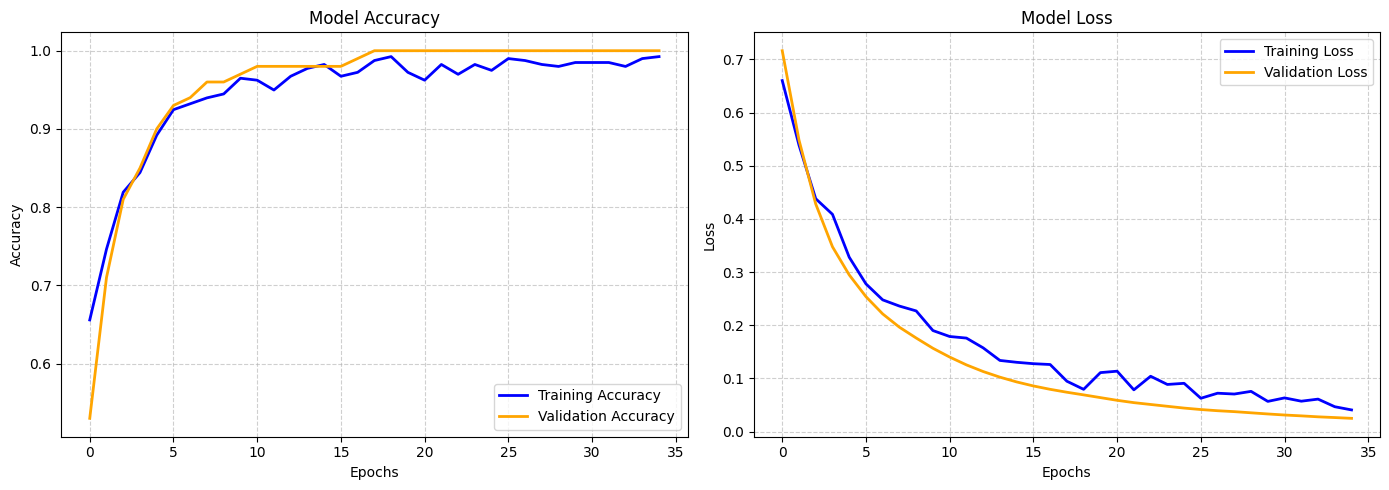

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

# Part 3: ResNet50 Model

In [13]:
base_model = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(img_width, img_height, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.25),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 68s 1us/step


In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 14,974,977 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights,
    callbacks=[
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
        callbacks.EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True),
        callbacks.ModelCheckpoint('resnet50_best_model.h5', save_best_only=True, monitor='val_loss')
    ]
)

model.save('resnet50_model.h5')

Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.6024 - loss: 0.6066

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 915ms/step - accuracy: 0.7538 - loss: 0.4622 - val_accuracy: 0.3700 - val_loss: 0.8638 - learning_rate: 1.0000e-05
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9166 - loss: 0.2562

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 771ms/step - accuracy: 0.9497 - loss: 0.2030 - val_accuracy: 0.3700 - val_loss: 0.8296 - learning_rate: 1.0000e-05
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9373 - loss: 0.1678

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 774ms/step - accuracy: 0.9447 - loss: 0.1689 - val_accuracy: 0.3700 - val_loss: 0.8228 - learning_rate: 1.0000e-05
Epoch 4/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 749ms/step - accuracy: 0.9673 - loss: 0.1104 - val_accuracy: 0.3700 - val_loss: 0.8342 - learning_rate: 1.0000e-05
Epoch 5/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 735ms/step - accuracy: 0.9548 - loss: 0.1198 - val_accuracy: 0.3700 - val_loss: 0.8338 - learning_rate: 1.0000e-05
Epoch 6/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 715ms/step - accuracy: 0.9698 - loss: 0.0893 - val_accuracy: 0.3700 - val_loss: 0.8248 - learning_rate: 2.0000e-06
Epoch 7/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9859 - loss: 0.0725

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 784ms/step - accuracy: 0.9824 - loss: 0.0742 - val_accuracy: 0.3800 - val_loss: 0.7917 - learning_rate: 2.0000e-06
Epoch 8/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9796 - loss: 0.1040

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 562ms/step - accuracy: 0.9849 - loss: 0.0493 - val_accuracy: 0.9900 - val_loss: 0.0918 - learning_rate: 2.0000e-06
Epoch 32/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9863 - loss: 0.0650

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 579ms/step - accuracy: 0.9899 - loss: 0.0570 - val_accuracy: 0.9900 - val_loss: 0.0882 - learning_rate: 2.0000e-06
Epoch 33/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9663 - loss: 0.0588

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 576ms/step - accuracy: 0.9749 - loss: 0.0478 - val_accuracy: 0.9900 - val_loss: 0.0851 - learning_rate: 2.0000e-06
Epoch 34/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9885 - loss: 0.0445

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 574ms/step - accuracy: 0.9899 - loss: 0.0461 - val_accuracy: 0.9900 - val_loss: 0.0804 - learning_rate: 2.0000e-06
Epoch 35/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9855 - loss: 0.0350

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 708ms/step - accuracy: 0.9849 - loss: 0.0400 - val_accuracy: 0.9900 - val_loss: 0.0763 - learning_rate: 2.0000e-06


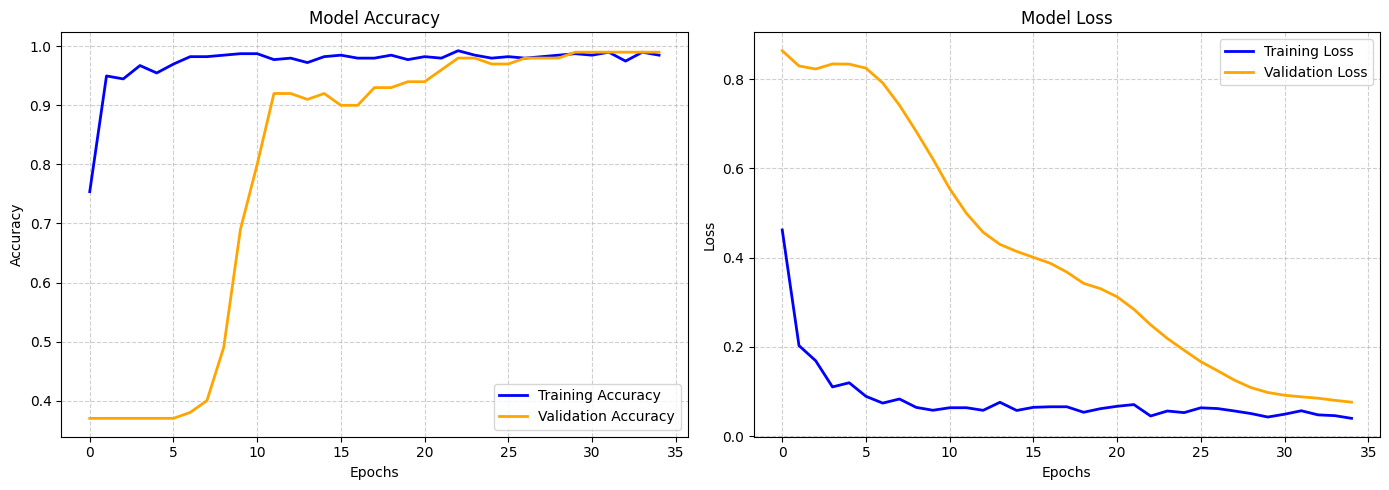

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

# Part 4: Testing & Inference
This section uses the last loaded model.

In [17]:
# 1. LOAD DATA & MODEL
model = load_model('resnet50_model.h5')
with open('./car_position_parking.pkl', 'rb') as f:
    posList = pickle.load(f)

# Box dimensions
width, height = 40, 65

# 2. VIDEO SETUP
cap = cv2.VideoCapture('parking.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('processed.mp4', fourcc, fps, (frame_w, frame_h))

# --- CONFIGURATION ---
SKIP_FRAMES = 2
last_results = []

def checkParkingSpace(img):
    img_crops = []
    active_positions = []

    # Get the target dimensions dynamically from the loaded model
    # model.input_shape is typically (None, height, width, channels)
    target_height = model.input_shape[1]
    target_width = model.input_shape[2]

    for pos in posList:
        x, y = pos
        imgCrop = img[y:y + height, x:x + width]

        if imgCrop.size == 0 or imgCrop.shape[0] < 5 or imgCrop.shape[1] < 5:
            continue

        imgResize = cv2.resize(imgCrop, (target_width, target_height), interpolation=cv2.INTER_LANCZOS4)
        imgNormalized = imgResize.astype('float32') / 255.0
        img_crops.append(imgNormalized)
        active_positions.append(pos)

    if len(img_crops) > 0:
        batch_array = np.array(img_crops)
        predictions = model.predict(batch_array, verbose=0)
        
        # Handle both Categorical (VGG16) and Binary (MobileNet) outputs
        if len(predictions.shape) > 1 and predictions.shape[1] == 1:
            class_indices = (predictions > 0.5).astype(int).flatten()
        else:
            class_indices = np.argmax(predictions, axis=1)
            
        return list(zip(active_positions, class_indices))
    return []

# 3. MAIN PROCESSING LOOP (Full Video)
for frame_idx in tqdm(range(total_frames), desc="Processing Full Video"):
    success, frame = cap.read()
    if not success:
        break

    # Update AI results every SKIP_FRAMES
    if frame_idx % SKIP_FRAMES == 0:
        last_results = checkParkingSpace(frame)

    # DRAWING LOGIC (3 CLASSES)
    for pos, class_idx in last_results:
        x, y = pos

        # 0: Reserved, 1: Unreserved
        if class_idx == 0:   # Reserved
            color, thickness = (0, 0, 255), 2  # Red
        else:                # Unreserved (1)
            color, thickness = (0, 255, 0), 2  # Green

        cv2.rectangle(frame, (x, y), (x + width, y + height), color, thickness)

    out.write(frame)

cap.release()
out.release()

Processing Full Video: 100%|██████████| 701/701 [15:12<00:00,  1.30s/it]
